# COS40007: AI FOR ENGINEERING
# Name: Muhammad Ashrull bin Rahmad
# Student ID: 102782025

# Step 1: Data Construction

In [1]:
# Import the libraries
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from scipy.signal import find_peaks
from scipy.integrate import trapezoid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets (Boning and Slicing inside ampc2)

boning_data = pd.read_csv("ampc2/Boning.csv")
slicing_data = pd.read_csv("ampc2/Slicing.csv")

# Check the dataset columns. Since my Student ID end with 5 then I will need to choose Right Upper Leg (x, y, z) and Left Upper Leg (x, y, z)

print(f"Columns: {list(boning_data.columns)}")


Columns: ['Frame', 'L5 x', 'L5 y', 'L5 z', 'L3 x', 'L3 y', 'L3 z', 'T12 x', 'T12 y', 'T12 z', 'T8 x', 'T8 y', 'T8 z', 'Neck x', 'Neck y', 'Neck z', 'Head x', 'Head y', 'Head z', 'Right Shoulder x', 'Right Shoulder y', 'Right Shoulder z', 'Right Upper Arm x', 'Right Upper Arm y', 'Right Upper Arm z', 'Right Forearm x', 'Right Forearm y', 'Right Forearm z', 'Right Hand x', 'Right Hand y', 'Right Hand z', 'Left Shoulder x', 'Left Shoulder y', 'Left Shoulder z', 'Left Upper Arm x', 'Left Upper Arm y', 'Left Upper Arm z', 'Left Forearm x', 'Left Forearm y', 'Left Forearm z', 'Left Hand x', 'Left Hand y', 'Left Hand z', 'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Right Lower Leg x', 'Right Lower Leg y', 'Right Lower Leg z', 'Right Foot x', 'Right Foot y', 'Right Foot z', 'Right Toe x', 'Right Toe y', 'Right Toe z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'Left Lower Leg x', 'Left Lower Leg y', 'Left Lower Leg z', 'Left Foot x', 'Left Foot y', 'Left Foo

In [3]:
# As stated inside the Assessment pdf, I will need to extract Frame along with 6 other columns which are Right Upper Leg (x, y, z) and Left Upper Leg (x, y, z) and the label for the classes (0: Boning | 1: Slicing)

extract_columns = ['Frame','Right Upper Leg x', 'Right Upper Leg y','Right Upper Leg z','Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z']

# Copying the required columns from both csv files
select_from_boning = boning_data[extract_columns].copy()
select_from_slicing = slicing_data[extract_columns].copy()

# Then they need to have their class labels (0: Boning | 1: Slicing)
select_from_boning['Class'] = 0
select_from_slicing['Class'] = 1

# After copying and added class labels for them, both of the datasets needs to be combined
dataset_combined = pd.concat([select_from_boning, select_from_slicing], ignore_index=True)

# Check to see if it have 8 columns or not then check the head of this new dataset
print(f"""Columns: {list(dataset_combined.columns)}
\nClass Distribution: \n{dataset_combined["Class"].value_counts()}""")

dataset_combined.head(20)

Columns: ['Frame', 'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'Class']

Class Distribution: 
Class
0    54180
1    17880
Name: count, dtype: int64


,Frame,Right Upper Leg x,Right Upper Leg y,Right Upper Leg z,Left Upper Leg x,Left Upper Leg y,Left Upper Leg z,Class
0,0,0.163942,-0.001378,0.045835,0.008039,-0.054908,0.011806,0
1,1,-0.190849,0.214363,0.051633,-0.541907,0.175742,0.231347,0
2,2,-0.054696,-0.127660,-0.076814,0.110754,0.134195,0.062618,0
3,3,0.184245,-0.046103,0.073129,0.013505,-0.010772,0.006895,0
4,4,0.302372,-0.010540,0.076275,0.210097,0.026873,0.017431,0
5,5,-0.457411,-0.208819,-0.114205,0.270895,0.024803,-0.131774,0
6,6,-0.275994,0.006827,-0.012993,-0.283351,-0.001029,-0.019028,0
7,7,-0.032263,0.042172,-0.073148,-0.395353,-0.079537,-0.016932,0
8,8,-0.052215,-0.104555,-0.142953,-0.115299,-0.210652,0.065820,0
9,9,0.358613,0.012029,0.076411,0.082238,-0.038966,0.134071,0


In [4]:
# After that, the new dataset needs to be saved as csv file and I stored it inside ampc2 folder
dataset_combined.to_csv('ampc2/Dataset_Combined_Step1.csv', index=False)

# Try to fetch the dataset
new_dataset_step1 = pd.read_csv('ampc2/Dataset_Combined_Step1.csv')
new_dataset_step1.head()

,Frame,Right Upper Leg x,Right Upper Leg y,Right Upper Leg z,Left Upper Leg x,Left Upper Leg y,Left Upper Leg z,Class
0,0,0.163942,-0.001378,0.045835,0.008039,-0.054908,0.011806,0
1,1,-0.190849,0.214363,0.051633,-0.541907,0.175742,0.231347,0
2,2,-0.054696,-0.127660,-0.076814,0.110754,0.134195,0.062618,0
3,3,0.184245,-0.046103,0.073129,0.013505,-0.010772,0.006895,0
4,4,0.302372,-0.010540,0.076275,0.210097,0.026873,0.017431,0


In [5]:
# Why these columns may contain useful motion information.
print("""Q1. These columns contain useful motion information as both boning and slicing require different posture and force exerted through body movements.\n
Boning typically uses more force since workers need to use their whole body for powerful pushing motions, with weight shifting through the legs for leverage.\n
Slicing on the other hand is more controlled and repetitive, with smoother and lighter lower body movements.\n""")

# How class labels affect model training (Label Shuffling Experiment)
# Will be put into appendix for this one
print("Q2. Class labels are essential for supervised learning. To prove this, we train the same model twice:")
print("    - Once with CORRECT labels (the real answer key)")
print("    - Once with RANDOM/SHUFFLED labels (a fake answer key)\n")

X = dataset_combined[['Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z',
                       'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z']]
y = dataset_combined['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train with correct labels
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
real_acc = accuracy_score(y_test, clf.predict(X_test))

# Train with random shuffled labels
y_train_shuffled = np.random.permutation(y_train)
clf_random = DecisionTreeClassifier(random_state=42)
clf_random.fit(X_train, y_train_shuffled)
random_acc = accuracy_score(y_test, clf_random.predict(X_test))

print(f"Accuracy with CORRECT labels: {real_acc:.4f}")
print(f"Accuracy with RANDOM labels:  {random_acc:.4f}")
print(f"\nConclusion: With correct labels the model learns to distinguish boning from slicing.")
print(f"With random labels it performs near 50% (random guessing), proving labels are the answer key that enables learning.")

Q1. These columns contain useful motion information as both boning and slicing require different posture and force exerted through body movements.

Boning typically uses more force since workers need to use their whole body for powerful pushing motions, with weight shifting through the legs for leverage.

Slicing on the other hand is more controlled and repetitive, with smoother and lighter lower body movements.

Q2. Class labels are essential for supervised learning. To prove this, we train the same model twice:
    - Once with CORRECT labels (the real answer key)
    - Once with RANDOM/SHUFFLED labels (a fake answer key)

Accuracy with CORRECT labels: 0.6740
Accuracy with RANDOM labels:  0.6212

Conclusion: With correct labels the model learns to distinguish boning from slicing.
With random labels it performs near 50% (random guessing), proving labels are the answer key that enables learning.


# Step 2: Create composite columns: Feature Engineering

In [6]:
# Next is creating composite columns for both Right Upper Leg (x, y, z) and Left Upper Leg (x, y, z) which then would create 12 new columns

# Save memory by using the variable used above
dataset_combined.head()

# Right Upper Leg first
# Extract values for the x, y, z
right_x = dataset_combined['Right Upper Leg x'].values
right_y = dataset_combined['Right Upper Leg y'].values
right_z = dataset_combined['Right Upper Leg z'].values

# New class labels along with their values
# 1. Root Mean Square for x and y
dataset_combined['RUL_RMS_xy'] = np.sqrt((right_x**2 + right_y**2) / 2)

# 2. Root Mean Square for y and z
dataset_combined['RUL_RMS_yz'] = np.sqrt((right_y**2 + right_z**2) / 2)

# 3. Root Mean Square for z and x
dataset_combined['RUL_RMS_zx'] = np.sqrt((right_z**2 + right_x**2) / 2)

# 4. Root Mean Square for x , y and z
dataset_combined['RUL_RMS_xyz'] = np.sqrt((right_x**2 + right_y**2 + right_z**2) / 3)

# 5. Roll
dataset_combined['RUL_Roll'] = np.degrees(np.arctan2(right_y, np.sqrt(right_x**2 + right_z**2)))

# 6. Pitch
dataset_combined['RUL_Pitch'] = np.degrees(np.arctan2(right_x, np.sqrt(right_y**2 + right_z**2)))

# Next is for Left Upper Leg
# Extract values for the x, y, z
left_x = dataset_combined['Left Upper Leg x'].values
left_y = dataset_combined['Left Upper Leg y'].values
left_z = dataset_combined['Left Upper Leg z'].values

# New class labels along with their values
# 1. Root Mean Square for x and y
dataset_combined['LUL_RMS_xy'] = np.sqrt((left_x**2 + left_y**2) / 2)

# 2. Root Mean Square for y and z
dataset_combined['LUL_RMS_yz'] = np.sqrt((left_y**2 + left_z**2) / 2)

# 3. Root Mean Square for z and x
dataset_combined['LUL_RMS_zx'] = np.sqrt((left_z**2 + left_x**2) / 2)

# 4. Root Mean Square for x , y and z
dataset_combined['LUL_RMS_xyz'] = np.sqrt((left_x**2 + left_y**2 + left_z**2) / 3)

# 5. Roll
dataset_combined['LUL_Roll'] = np.degrees(np.arctan2(left_y, np.sqrt(left_x**2 + left_z**2)))

# 6. Pitch
dataset_combined['LUL_Pitch'] = np.degrees(np.arctan2(left_x, np.sqrt(left_y**2 + left_z**2)))

# Then columns needs to be reordered
ordered_cols = [
    'Frame',
    'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z',
    'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z',
    'RUL_RMS_xy', 'RUL_RMS_yz', 'RUL_RMS_zx', 'RUL_RMS_xyz', 'RUL_Roll', 'RUL_Pitch',
    'LUL_RMS_xy', 'LUL_RMS_yz', 'LUL_RMS_zx', 'LUL_RMS_xyz', 'LUL_Roll', 'LUL_Pitch',
    'Class'
]

dataset_combined = dataset_combined[ordered_cols]

# Check to see if it have 8 columns or not then check the head of this new dataset
print(f"""Columns: {list(dataset_combined.columns)}
Columns length: {len(dataset_combined.columns)}
\nClass Distribution: \n{dataset_combined["Class"].value_counts()}""")

dataset_combined.head()


Columns: ['Frame', 'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'RUL_RMS_xy', 'RUL_RMS_yz', 'RUL_RMS_zx', 'RUL_RMS_xyz', 'RUL_Roll', 'RUL_Pitch', 'LUL_RMS_xy', 'LUL_RMS_yz', 'LUL_RMS_zx', 'LUL_RMS_xyz', 'LUL_Roll', 'LUL_Pitch', 'Class']
Columns length: 20

Class Distribution: 
Class
0    54180
1    17880
Name: count, dtype: int64


,Frame,Right Upper Leg x,Right Upper Leg y,Right Upper Leg z,Left Upper Leg x,Left Upper Leg y,Left Upper Leg z,RUL_RMS_xy,RUL_RMS_yz,RUL_RMS_zx,RUL_RMS_xyz,RUL_Roll,RUL_Pitch,LUL_RMS_xy,LUL_RMS_yz,LUL_RMS_zx,LUL_RMS_xyz,LUL_Roll,LUL_Pitch,Class
0,0,0.163942,-0.001378,0.045835,0.008039,-0.054908,0.011806,0.115929,0.032425,0.120370,0.098285,-0.463874,74.373477,0.039240,0.039713,0.010099,0.032756,-75.419216,8.145627,0
1,1,-0.190849,0.214363,0.051633,-0.541907,0.175742,0.231347,0.202947,0.155913,0.139802,0.168366,47.314250,-40.877851,0.402833,0.205435,0.416644,0.354998,16.607725,-61.803248,0
2,2,-0.054696,-0.127660,-0.076814,0.110754,0.134195,0.062618,0.098206,0.105351,0.066679,0.091632,-53.547907,-20.159073,0.123034,0.104712,0.089965,0.106764,46.526066,36.793194,0
3,3,0.184245,-0.046103,0.073129,0.013505,-0.010772,0.006895,0.134298,0.061128,0.140168,0.117501,-13.092780,64.863929,0.012215,0.009044,0.010722,0.010739,-35.390217,46.558178,0
4,4,0.302372,-0.010540,0.076275,0.210097,0.026873,0.017431,0.213939,0.054447,0.220507,0.180146,-1.935793,75.713140,0.149771,0.022649,0.149071,0.122701,7.264199,81.331620,0


In [7]:
# Then save the new composite dataset into csv file

dataset_combined.to_csv('ampc2/Dataset_Composite_Step2.csv', index=False)

# Try to fetch the dataset
new_dataset_step2 = pd.read_csv('ampc2/Dataset_Composite_Step2.csv')
new_dataset_step2.head()


,Frame,Right Upper Leg x,Right Upper Leg y,Right Upper Leg z,Left Upper Leg x,Left Upper Leg y,Left Upper Leg z,RUL_RMS_xy,RUL_RMS_yz,RUL_RMS_zx,RUL_RMS_xyz,RUL_Roll,RUL_Pitch,LUL_RMS_xy,LUL_RMS_yz,LUL_RMS_zx,LUL_RMS_xyz,LUL_Roll,LUL_Pitch,Class
0,0,0.163942,-0.001378,0.045835,0.008039,-0.054908,0.011806,0.115929,0.032425,0.120370,0.098285,-0.463874,74.373477,0.039240,0.039713,0.010099,0.032756,-75.419216,8.145627,0
1,1,-0.190849,0.214363,0.051633,-0.541907,0.175742,0.231347,0.202947,0.155913,0.139802,0.168366,47.314250,-40.877851,0.402833,0.205435,0.416644,0.354998,16.607725,-61.803248,0
2,2,-0.054696,-0.127660,-0.076814,0.110754,0.134195,0.062618,0.098206,0.105351,0.066679,0.091632,-53.547907,-20.159073,0.123034,0.104712,0.089965,0.106764,46.526066,36.793194,0
3,3,0.184245,-0.046103,0.073129,0.013505,-0.010772,0.006895,0.134298,0.061128,0.140168,0.117501,-13.092780,64.863929,0.012215,0.009044,0.010722,0.010739,-35.390217,46.558178,0
4,4,0.302372,-0.010540,0.076275,0.210097,0.026873,0.017431,0.213939,0.054447,0.220507,0.180146,-1.935793,75.713140,0.149771,0.022649,0.149071,0.122701,7.264199,81.331620,0


# Step 3: Data pre-processing and Feature computation: Feature Engineering

In [8]:
# Next we will go through Data pre-processing and Feature computation. On this step, statistical features is computed per minute from columns 2-19 (18 columns in total)

# Compute:
# 1. Mean
# 2. Standard Deviation
# 3. Min
# 4. Max
# 5. Area Under the Curve (AOC)
# 6. Number of Peaks

# Meaning later there would be 18 columns x 6 features = 108 features

# Extract needed columns

feature_columns = [col for col in dataset_combined.columns if col not in ['Frame', 'Class']]
print(f'Number of feature columns: {len(feature_columns)}')
print(f'Feature columns: {feature_columns}')

Number of feature columns: 18
Feature columns: ['Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'RUL_RMS_xy', 'RUL_RMS_yz', 'RUL_RMS_zx', 'RUL_RMS_xyz', 'RUL_Roll', 'RUL_Pitch', 'LUL_RMS_xy', 'LUL_RMS_yz', 'LUL_RMS_zx', 'LUL_RMS_xyz', 'LUL_Roll', 'LUL_Pitch']


In [9]:
# Each activity is processed separately to maintain proper frame grouping

all_features = []

for class_val in [0, 1]:
    class_data = dataset_combined[dataset_combined['Class'] == class_val].reset_index(drop=True)
    n_minutes = len(class_data) // 60
    
    for i in range(n_minutes):
        start_idx = i * 60
        end_idx = start_idx + 60
        group = class_data.iloc[start_idx:end_idx]
        
        features = {}
        for col in feature_columns:
            values = group[col].values
            # Mean
            features[f'{col}_mean'] = np.mean(values)
            # Standard deviation
            features[f'{col}_std'] = np.std(values)
            # Minimum
            features[f'{col}_min'] = np.min(values)
            # Maximum
            features[f'{col}_max'] = np.max(values)
            # Area under the curve
            features[f'{col}_auc'] = trapezoid(values)
            # Peaks
            peaks, _ = find_peaks(values)
            features[f'{col}_peaks'] = len(peaks)
        features['Class'] = class_val
        all_features.append(features)

# Create features dataframe
features_df = pd.DataFrame(all_features)

print(f'Statistical features dataset shape: {features_df.shape}')
print(f'Number of features: {features_df.shape[1] - 1}')  # Exclude class column
print(f'\nClass distribution:\n{features_df["Class"].value_counts()}')
print(f'\nFirst few feature names: {list(features_df.columns[:12])}')
features_df.head()

Statistical features dataset shape: (1201, 109)
Number of features: 108

Class distribution:
Class
0    903
1    298
Name: count, dtype: int64

First few feature names: ['Right Upper Leg x_mean', 'Right Upper Leg x_std', 'Right Upper Leg x_min', 'Right Upper Leg x_max', 'Right Upper Leg x_auc', 'Right Upper Leg x_peaks', 'Right Upper Leg y_mean', 'Right Upper Leg y_std', 'Right Upper Leg y_min', 'Right Upper Leg y_max', 'Right Upper Leg y_auc', 'Right Upper Leg y_peaks']


,Right Upper Leg x_mean,Right Upper Leg x_std,Right Upper Leg x_min,Right Upper Leg x_max,Right Upper Leg x_auc,Right Upper Leg x_peaks,Right Upper Leg y_mean,Right Upper Leg y_std,Right Upper Leg y_min,Right Upper Leg y_max,...,LUL_Roll_max,LUL_Roll_auc,LUL_Roll_peaks,LUL_Pitch_mean,LUL_Pitch_std,LUL_Pitch_min,LUL_Pitch_max,LUL_Pitch_auc,LUL_Pitch_peaks,Class
0,-0.001113,0.315702,-1.265566,0.695836,0.484026,17,0.019689,0.192138,-0.490542,0.486680,...,80.737426,42.025675,18,4.416288,47.940777,-86.152509,86.509030,254.258799,16,0
1,0.091712,0.974851,-3.669763,2.055587,6.062526,16,0.099387,0.906952,-1.934838,3.170147,...,72.237900,-175.199194,18,-1.625191,39.779017,-80.436679,79.578208,-50.219014,14,0
2,-0.022117,2.105375,-6.197321,5.862352,-0.661989,15,-0.088690,1.908074,-6.493498,6.450496,...,79.129511,-444.312348,12,-0.308967,42.679785,-81.390961,70.731977,17.144260,13,0
3,-0.046819,0.908123,-1.818145,2.035438,-3.451882,15,-0.034242,1.263692,-2.982111,3.328416,...,82.952174,-55.581562,16,-1.258587,35.563653,-74.488492,88.350592,-103.762641,16,0
4,-0.011843,1.317380,-3.478682,3.122995,-0.585214,13,0.023539,1.406166,-3.746447,3.374788,...,71.816961,-602.125974,17,-1.929428,36.904239,-76.482220,64.834288,-143.129970,18,0


In [10]:
# Then save the new feature dataset into csv file

features_df.to_csv('ampc2/Dataset_Features_Step3.csv', index=False)

# Try to fetch the dataset
new_dataset_step3 = pd.read_csv('ampc2/Dataset_Features_Step3.csv')
new_dataset_step3.head()

,Right Upper Leg x_mean,Right Upper Leg x_std,Right Upper Leg x_min,Right Upper Leg x_max,Right Upper Leg x_auc,Right Upper Leg x_peaks,Right Upper Leg y_mean,Right Upper Leg y_std,Right Upper Leg y_min,Right Upper Leg y_max,...,LUL_Roll_max,LUL_Roll_auc,LUL_Roll_peaks,LUL_Pitch_mean,LUL_Pitch_std,LUL_Pitch_min,LUL_Pitch_max,LUL_Pitch_auc,LUL_Pitch_peaks,Class
0,-0.001113,0.315702,-1.265566,0.695836,0.484026,17,0.019689,0.192138,-0.490542,0.486680,...,80.737426,42.025675,18,4.416288,47.940777,-86.152509,86.509030,254.258799,16,0
1,0.091712,0.974851,-3.669763,2.055587,6.062526,16,0.099387,0.906952,-1.934838,3.170147,...,72.237900,-175.199194,18,-1.625191,39.779017,-80.436679,79.578208,-50.219014,14,0
2,-0.022117,2.105375,-6.197321,5.862352,-0.661989,15,-0.088690,1.908074,-6.493498,6.450496,...,79.129511,-444.312348,12,-0.308967,42.679785,-81.390961,70.731977,17.144260,13,0
3,-0.046819,0.908123,-1.818145,2.035438,-3.451882,15,-0.034242,1.263692,-2.982111,3.328416,...,82.952174,-55.581562,16,-1.258587,35.563653,-74.488492,88.350592,-103.762641,16,0
4,-0.011843,1.317380,-3.478682,3.122995,-0.585214,13,0.023539,1.406166,-3.746447,3.374788,...,71.816961,-602.125974,17,-1.929428,36.904239,-76.482220,64.834288,-143.129970,18,0


In [11]:
# Why statistical summarisation is useful for sensor signals
print("Q3. If we take into account about the noise, having frame by frame acceleration values would be very noisy, thus by aggregating it over 60 frames, it will help smoothen fluctuations caused by too much noise. Not only that, features like mean, std, min, max capture the central tendency, variability, and range of motion within each time window")

# Possible disadvantages of many features.
print("Q4. With the limited samples that we have, 108 features would be overkill as it makes the feature space becomes sparse thus the it will be hard for the model to find the patterns that is meaningful. Overfitting would be a probelm as well since the model would highly likely to just memorize training data as there are too many features relative to samples.")

Q3. If we take into account about the noise, having frame by frame acceleration values would be very noisy, thus by aggregating it over 60 frames, it will help smoothen fluctuations caused by too much noise. Not only that, features like mean, std, min, max capture the central tendency, variability, and range of motion within each time window
Q4. With the limited samples that we have, 108 features would be overkill as it makes the feature space becomes sparse thus the it will be hard for the model to find the patterns that is meaningful. Overfitting would be a probelm as well since the model would highly likely to just memorize training data as there are too many features relative to samples.


# Step 4: Training: Model Development

In [12]:
# 1. Train-Test Split (70/30)

# First of all, the data needs to be prepared
# Prepare the data
X = features_df.drop('Class', axis=1)
y = features_df['Class']

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-Test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Training class distribution:\n{y_train.value_counts()}')
print(f'Test class distribution:\n{y_test.value_counts()}')

Training set: (840, 108)
Test set: (361, 108)
Training class distribution:
Class
0    632
1    208
Name: count, dtype: int64
Test class distribution:
Class
0    271
1     90
Name: count, dtype: int64


In [13]:
# Store results for summary table
results = []

# ---- 1. SVM with Train-Test Split (70/30) ----
svm_basic = svm.SVC(kernel='rbf', random_state=42)
svm_basic.fit(X_train, y_train)
y_pred_basic = svm_basic.predict(X_test)
acc_basic_tt = accuracy_score(y_test, y_pred_basic)

print('=== 1. SVM - Train-Test Split (70/30) ===')
print(f'Accuracy: {acc_basic_tt:.4f}')
print(classification_report(y_test, y_pred_basic, target_names=['Boning', 'Slicing']))

=== 1. SVM - Train-Test Split (70/30) ===
Accuracy: 0.8809
              precision    recall  f1-score   support

      Boning       0.90      0.95      0.92       271
     Slicing       0.82      0.67      0.74        90

    accuracy                           0.88       361
   macro avg       0.86      0.81      0.83       361
weighted avg       0.88      0.88      0.88       361



In [14]:
# ---- 2. SVM with 10-Fold Cross Validation ----
svm_cv = svm.SVC(kernel='rbf', random_state=42)
cv_scores = cross_val_score(svm_cv, X_scaled, y, cv=10, scoring='accuracy')
acc_basic_cv = cv_scores.mean()

print('\n=== 2. SVM - 10-Fold Cross Validation ===')
print(f'CV Scores: {cv_scores}')
print(f'Mean Accuracy: {acc_basic_cv:.4f} (+/- {cv_scores.std():.4f})')

results.append({'Model': 'SVM (basic)', 'Train-Test (70/30)': f'{acc_basic_tt:.4f}', '10-Fold CV': f'{acc_basic_cv:.4f}'})


=== 2. SVM - 10-Fold Cross Validation ===
CV Scores: [0.85950413 0.90833333 0.89166667 0.88333333 0.825      0.85833333
 0.89166667 0.88333333 0.93333333 0.85      ]
Mean Accuracy: 0.8785 (+/- 0.0296)


In [15]:
# ---- 3. 1 and 2 with Hyperparameter Tuning ----
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(svm.SVC(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('=== 3. SVM with Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')

# Train-Test with best params
best_svm = grid_search.best_estimator_
y_pred_tuned = best_svm.predict(X_test)
acc_tuned_tt = accuracy_score(y_test, y_pred_tuned)

# 10-Fold CV with best params
cv_scores_tuned = cross_val_score(best_svm, X_scaled, y, cv=10, scoring='accuracy')
acc_tuned_cv = cv_scores_tuned.mean()

print(f'Train-Test Accuracy: {acc_tuned_tt:.4f}')
print(f'10-Fold CV Accuracy: {acc_tuned_cv:.4f}')
print(classification_report(y_test, y_pred_tuned, target_names=['Boning', 'Slicing']))

results.append({'Model': 'SVM (tuned)', 'Train-Test (70/30)': f'{acc_tuned_tt:.4f}', '10-Fold CV': f'{acc_tuned_cv:.4f}'})

=== 3. SVM with Hyperparameter Tuning ===
Best Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.8881
Train-Test Accuracy: 0.8781
10-Fold CV Accuracy: 0.8768
              precision    recall  f1-score   support

      Boning       0.89      0.95      0.92       271
     Slicing       0.82      0.66      0.73        90

    accuracy                           0.88       361
   macro avg       0.86      0.80      0.82       361
weighted avg       0.87      0.88      0.87       361



In [16]:
# ---- 4. 1 and 2 with Hyperparameter Tuning + 10 Best Features ----
selector = SelectKBest(f_classif, k=10)
X_train_best = selector.fit_transform(X_train, y_train)
X_test_best = selector.transform(X_test)
X_scaled_best = selector.transform(X_scaled)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print('=== 4. SVM with Hyperparameter Tuning + 10 Best Features ===')
print(f'Selected features: {list(selected_features)}')

# Grid search on selected features
grid_search_best = GridSearchCV(svm.SVC(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search_best.fit(X_train_best, y_train)

print(f'Best Parameters: {grid_search_best.best_params_}')

# Train-Test with best features
best_svm_feat = grid_search_best.best_estimator_
y_pred_feat = best_svm_feat.predict(X_test_best)
acc_feat_tt = accuracy_score(y_test, y_pred_feat)

# 10-Fold CV with best features
cv_scores_feat = cross_val_score(best_svm_feat, X_scaled_best, y, cv=10, scoring='accuracy')
acc_feat_cv = cv_scores_feat.mean()

print(f'Train-Test Accuracy: {acc_feat_tt:.4f}')
print(f'10-Fold CV Accuracy: {acc_feat_cv:.4f}')
print(classification_report(y_test, y_pred_feat, target_names=['Boning', 'Slicing']))

results.append({'Model': 'SVM (tuned + 10 best)', 'Train-Test (70/30)': f'{acc_feat_tt:.4f}', '10-Fold CV': f'{acc_feat_cv:.4f}'})

=== 4. SVM with Hyperparameter Tuning + 10 Best Features ===
Selected features: ['Right Upper Leg x_peaks', 'Left Upper Leg x_peaks', 'RUL_RMS_xy_peaks', 'RUL_RMS_zx_peaks', 'RUL_RMS_xyz_peaks', 'RUL_Pitch_peaks', 'LUL_RMS_xy_peaks', 'LUL_RMS_zx_peaks', 'LUL_RMS_xyz_peaks', 'LUL_Pitch_peaks']
Best Parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Train-Test Accuracy: 0.8476
10-Fold CV Accuracy: 0.8401
              precision    recall  f1-score   support

      Boning       0.85      0.96      0.90       271
     Slicing       0.82      0.50      0.62        90

    accuracy                           0.85       361
   macro avg       0.84      0.73      0.76       361
weighted avg       0.84      0.85      0.83       361



In [17]:
# ---- 5. SVM with Hyperparameter Tuning + 10 Principal Components ----
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_scaled_pca = pca.transform(X_scaled)

print('=== 5. SVM with Hyperparameter Tuning + 10 Principal Components ===')
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.4f}')

# Grid search on PCA components
grid_search_pca = GridSearchCV(svm.SVC(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search_pca.fit(X_train_pca, y_train)

print(f'Best Parameters: {grid_search_pca.best_params_}')

# Train-Test with PCA
best_svm_pca = grid_search_pca.best_estimator_
y_pred_pca = best_svm_pca.predict(X_test_pca)
acc_pca_tt = accuracy_score(y_test, y_pred_pca)

# 10-Fold CV with PCA
cv_scores_pca = cross_val_score(best_svm_pca, X_scaled_pca, y, cv=10, scoring='accuracy')
acc_pca_cv = cv_scores_pca.mean()

print(f'Train-Test Accuracy: {acc_pca_tt:.4f}')
print(f'10-Fold CV Accuracy: {acc_pca_cv:.4f}')
print(classification_report(y_test, y_pred_pca, target_names=['Boning', 'Slicing']))

results.append({'Model': 'SVM (tuned + 10 PCA)', 'Train-Test (70/30)': f'{acc_pca_tt:.4f}', '10-Fold CV': f'{acc_pca_cv:.4f}'})

=== 5. SVM with Hyperparameter Tuning + 10 Principal Components ===
Explained variance ratio: [0.35091669 0.0880685  0.06043412 0.05786891 0.03707719 0.02968039
 0.02545764 0.02483753 0.02106977 0.0196138 ]
Total variance explained: 0.7150
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Train-Test Accuracy: 0.8615
10-Fold CV Accuracy: 0.8718
              precision    recall  f1-score   support

      Boning       0.88      0.94      0.91       271
     Slicing       0.78      0.62      0.69        90

    accuracy                           0.86       361
   macro avg       0.83      0.78      0.80       361
weighted avg       0.86      0.86      0.86       361



In [18]:
# ---- SVM Summary Table ----
svm_results_df = pd.DataFrame(results)
print('\n========== SVM RESULTS SUMMARY ==========')
print(svm_results_df.to_string(index=False))


========== SVM RESULTS SUMMARY ==========
                Model Train-Test (70/30) 10-Fold CV
          SVM (basic)             0.8809     0.8785
          SVM (tuned)             0.8781     0.8768
SVM (tuned + 10 best)             0.8476     0.8401
 SVM (tuned + 10 PCA)             0.8615     0.8718


In [19]:
# ---- Train SGD, RandomForest, and MLP Classifiers using Original Dataset (Step 1) ----
other_results = []

# Prepare original dataset from Step 1
X_orig = new_dataset_step1[['Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z',
                       'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z']]
y_orig = new_dataset_step1['Class']

# Standardize
scaler_orig = StandardScaler()
X_orig_scaled = pd.DataFrame(scaler_orig.fit_transform(X_orig), columns=X_orig.columns)

# Train-Test split (70/30)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig_scaled, y_orig, test_size=0.3, random_state=42, stratify=y_orig
)

print(f'Original dataset - Training set: {X_train_orig.shape}, Test set: {X_test_orig.shape}')
print(f'Training class distribution:\n{y_train_orig.value_counts().rename({0: "Boning (0)", 1: "Slicing (1)"})}')
print(f'Test class distribution:\n{y_test_orig.value_counts().rename({0: "Boning (0)", 1: "Slicing (1)"})}\n')

# SGD Classifier
sgd = SGDClassifier(random_state=42, max_iter=1000, class_weight='balanced')
sgd.fit(X_train_orig, y_train_orig)
sgd_tt_acc = accuracy_score(y_test_orig, sgd.predict(X_test_orig))
sgd_cv_scores = cross_val_score(sgd, X_orig_scaled, y_orig, cv=10, scoring='accuracy')
sgd_cv_acc = sgd_cv_scores.mean()

print('=== SGD Classifier ===')
print(f'Train-Test Accuracy: {sgd_tt_acc:.4f}')
print(f'10-Fold CV Accuracy: {sgd_cv_acc:.4f}')
print(classification_report(y_test_orig, sgd.predict(X_test_orig), target_names=['Boning', 'Slicing']))

other_results.append({'Model': 'SGD', 'Train-Test (70/30)': f'{sgd_tt_acc:.4f}', '10-Fold CV': f'{sgd_cv_acc:.4f}'})

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_orig, y_train_orig)
rf_tt_acc = accuracy_score(y_test_orig, rf.predict(X_test_orig))
rf_cv_scores = cross_val_score(rf, X_orig_scaled, y_orig, cv=10, scoring='accuracy')
rf_cv_acc = rf_cv_scores.mean()

print('\n=== Random Forest Classifier ===')
print(f'Train-Test Accuracy: {rf_tt_acc:.4f}')
print(f'10-Fold CV Accuracy: {rf_cv_acc:.4f}')
print(classification_report(y_test_orig, rf.predict(X_test_orig), target_names=['Boning', 'Slicing']))

other_results.append({'Model': 'Random Forest', 'Train-Test (70/30)': f'{rf_tt_acc:.4f}', '10-Fold CV': f'{rf_cv_acc:.4f}'})

# MLP Classifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_orig, y_train_orig)
mlp_tt_acc = accuracy_score(y_test_orig, mlp.predict(X_test_orig))
mlp_cv_scores = cross_val_score(mlp, X_orig_scaled, y_orig, cv=10, scoring='accuracy')
mlp_cv_acc = mlp_cv_scores.mean()

print('\n=== MLP Classifier ===')
print(f'Train-Test Accuracy: {mlp_tt_acc:.4f}')
print(f'10-Fold CV Accuracy: {mlp_cv_acc:.4f}')
print(classification_report(y_test_orig, mlp.predict(X_test_orig), target_names=['Boning', 'Slicing']))

other_results.append({'Model': 'MLP', 'Train-Test (70/30)': f'{mlp_tt_acc:.4f}', '10-Fold CV': f'{mlp_cv_acc:.4f}'})

Original dataset - Training set: (50442, 6), Test set: (21618, 6)
Training class distribution:
Class
Boning (0)     37926
Slicing (1)    12516
Name: count, dtype: int64
Test class distribution:
Class
Boning (0)     16254
Slicing (1)     5364
Name: count, dtype: int64

=== SGD Classifier ===
Train-Test Accuracy: 0.3603
10-Fold CV Accuracy: 0.5475
              precision    recall  f1-score   support

      Boning       0.81      0.20      0.32     16254
     Slicing       0.26      0.86      0.40      5364

    accuracy                           0.36     21618
   macro avg       0.53      0.53      0.36     21618
weighted avg       0.67      0.36      0.34     21618


=== Random Forest Classifier ===
Train-Test Accuracy: 0.7673
10-Fold CV Accuracy: 0.7651
              precision    recall  f1-score   support

      Boning       0.79      0.95      0.86     16254
     Slicing       0.58      0.21      0.31      5364

    accuracy                           0.77     21618
   macro avg     

In [20]:
# ---- Combined Results Table ----
all_results = results + other_results
all_results_df = pd.DataFrame(all_results)
print('\n========== ALL MODELS RESULTS SUMMARY ==========')
print(all_results_df.to_string(index=False))


========== ALL MODELS RESULTS SUMMARY ==========
                Model Train-Test (70/30) 10-Fold CV
          SVM (basic)             0.8809     0.8785
          SVM (tuned)             0.8781     0.8768
SVM (tuned + 10 best)             0.8476     0.8401
 SVM (tuned + 10 PCA)             0.8615     0.8718
                  SGD             0.3603     0.5475
        Random Forest             0.7673     0.7651
                  MLP             0.7685     0.7633


In [21]:
# Which models are linear vs nonlinear
print("Q5. So for the models used, SVM with a linear kernel and SGD Classifier would be the ones that are linear since SVM with a linear kernel finds a straight line or boundary between the two classes while SGD by default uses linear loss functions which means it also relies on straight decision boundaries. On the other hand, SVM with RBF or poly kernel, Random Forest, and MLP would be the ones that are nonlinear since SVM with RBF or poly kernel uses the kernel trick to map the data into a higher space to find curved boundaries while Random Forest is basically a bunch of decision trees working together that can capture complex nonlinear patterns and MLP which is basically a neural network uses hidden layers with nonlinear activation functions that allows it to learn complex relationships in the data.")

# Which models may work better for high-dimensional data
print("Q6. SVM would be the one that tends to do well with lots of features since it finds the best boundary to separate the classes and uses kernel tricks to handle nonlinear boundaries which makes it work well even when the number of features is large like our 108 features. Random Forest would also be the one that handles lots of features well since it picks random features at each split which makes it able to ignore features that do not matter. MLP can learn complex patterns with lots of features through its layers but it requires more data and careful tuning to work well. SGD on the other hand may struggle with lots of features if the features are related to each other since it relies on straight decision boundaries which might not be enough to separate the classes properly when the data is complex.")

Q5. So for the models used, SVM with a linear kernel and SGD Classifier would be the ones that are linear since SVM with a linear kernel finds a straight line or boundary between the two classes while SGD by default uses linear loss functions which means it also relies on straight decision boundaries. On the other hand, SVM with RBF or poly kernel, Random Forest, and MLP would be the ones that are nonlinear since SVM with RBF or poly kernel uses the kernel trick to map the data into a higher space to find curved boundaries while Random Forest is basically a bunch of decision trees working together that can capture complex nonlinear patterns and MLP which is basically a neural network uses hidden layers with nonlinear activation functions that allows it to learn complex relationships in the data.
Q6. SVM would be the one that tends to do well with lots of features since it finds the best boundary to separate the classes and uses kernel tricks to handle nonlinear boundaries which makes i

# Step 5: Model Improvement Experiments

========== SVM MODEL IMPROVEMENT COMPARISON ==========
                  Configuration  Train-Test Accuracy  10-Fold CV Accuracy
        SVM (Basic - no tuning)             0.880886             0.878450
     SVM (Hyperparameter Tuned)             0.878116             0.876784
 SVM (Tuned + 10 Best Features)             0.847645             0.840138
SVM (Tuned + 10 PCA Components)             0.861496             0.871791


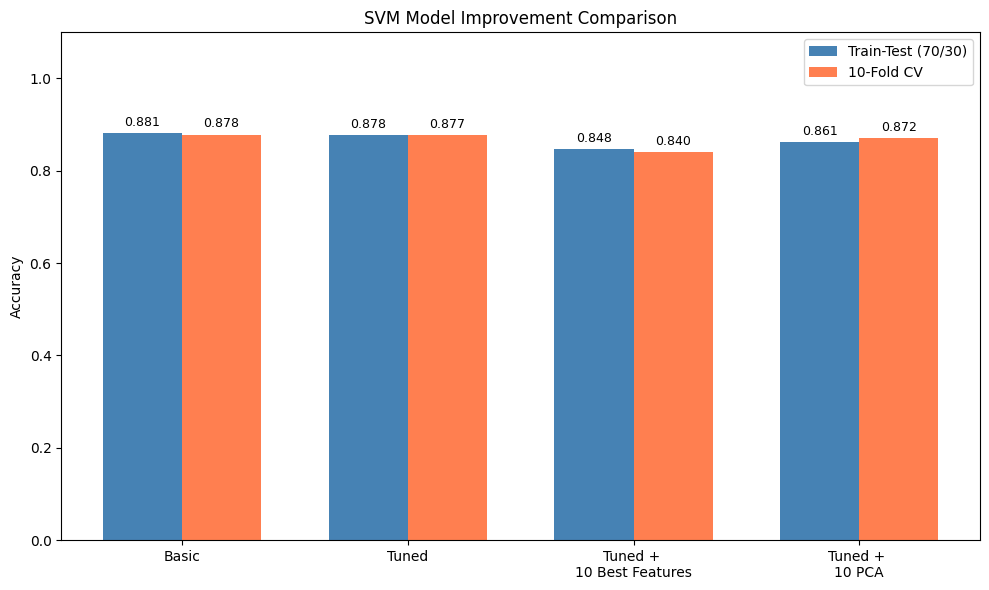

In [22]:
# ---- Step 5: Model Improvement Comparison ----
improvement_data = {
    'Configuration': [
        'SVM (Basic - no tuning)',
        'SVM (Hyperparameter Tuned)',
        'SVM (Tuned + 10 Best Features)',
        'SVM (Tuned + 10 PCA Components)'
    ],
    'Train-Test Accuracy': [acc_basic_tt, acc_tuned_tt, acc_feat_tt, acc_pca_tt],
    '10-Fold CV Accuracy': [acc_basic_cv, acc_tuned_cv, acc_feat_cv, acc_pca_cv]
}

improvement_df = pd.DataFrame(improvement_data)
print('========== SVM MODEL IMPROVEMENT COMPARISON ==========')
print(improvement_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(improvement_data['Configuration']))
width = 0.35

bars1 = ax.bar(x - width/2, improvement_data['Train-Test Accuracy'], width, label='Train-Test (70/30)', color='steelblue')
bars2 = ax.bar(x + width/2, improvement_data['10-Fold CV Accuracy'], width, label='10-Fold CV', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('SVM Model Improvement Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Basic', 'Tuned', 'Tuned + \n10 Best Features', 'Tuned + \n10 PCA'], rotation=0)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Did dimensionality reduction improve the model?
print("Q7. No, in this case dimensionality reduction did not improve the model. The results show that SVM with all 108 features got 0.8809 for train-test and 0.8785 for CV while SVM with 10 best features got 0.8476 for train-test and 0.8401 for CV which is a decrease and SVM with 10 PCA components got 0.8615 for train-test and 0.8718 for CV which is also a slight decrease. Both feature selection and PCA reduced the performance compared to using all 108 features")

# Why might this happen?
print("Q8. So the main reason would be that reducing from 108 down to just 10 features or components is a very big reduction since we are only keeping around 9%\ of the original features which means a lot of useful information gets lost. PCA only kept 71.5%\ of the total variance with 10 components and since PCA does not care about the class labels, the thrown away 28.5% variance may actually contain patterns that help tell boning apart from slicing. Not only that, SelectKBest chose mostly peaks features which may not fully capture the differences between the two activities since the selected features may miss other useful information from like mean, std, or AUC features that help with the classification accuracy when used together. SVM with RBF kernel is also already good at working with lots of features due to the kernel trick so it does not suffer as much from having too many features as other models might with 108 features which means reducing the features was actually hurting more than helping in this case.")

Q7. No, in this case dimensionality reduction did not improve the model. The results show that SVM with all 108 features got 0.8809 for train-test and 0.8785 for CV while SVM with 10 best features got 0.8476 for train-test and 0.8401 for CV which is a decrease and SVM with 10 PCA components got 0.8615 for train-test and 0.8718 for CV which is also a slight decrease. Both feature selection and PCA reduced the performance compared to using all 108 features
Q8. So the main reason would be that reducing from 108 down to just 10 features or components is a very big reduction since we are only keeping around 9%\ of the original features which means a lot of useful information gets lost. PCA only kept 71.5%\ of the total variance with 10 components and since PCA does not care about the class labels, the thrown away 28.5% variance may actually contain patterns that help tell boning apart from slicing. Not only that, SelectKBest chose mostly peaks features which may not fully capture the differ

<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
C:\Users\muhda\AppData\Local\Temp\ipykernel_24880\419983355.py:5: SyntaxWarning: invalid escape sequence '\ '
  print("Q8. So the main reason would be that reducing from 108 down to just 10 features or components is a very big reduction since we are only keeping around 9%\ of the original features which means a lot of useful information gets lost. PCA only kept 71.5%\ of the total variance with 10 components and since PCA does not care about the class labels, the thrown away 28.5% variance may actually contain patterns that help tell boning apart from slicing. Not only that, SelectKBest chose mostly peaks features which may not fully capture the differences between the two activities since the selected features may miss other useful information from like mean, std, or AUC features that help with the classification accuracy when used together. SVM with RBF kernel is also already good at w

# Step 6: Model Evaluation and Selection

========== FINAL MODEL COMPARISON ==========
                Model Train-Test (70/30) 10-Fold CV
          SVM (basic)             0.8809     0.8785
          SVM (tuned)             0.8781     0.8768
SVM (tuned + 10 best)             0.8476     0.8401
 SVM (tuned + 10 PCA)             0.8615     0.8718
                  SGD             0.3603     0.5475
        Random Forest             0.7673     0.7651
                  MLP             0.7685     0.7633


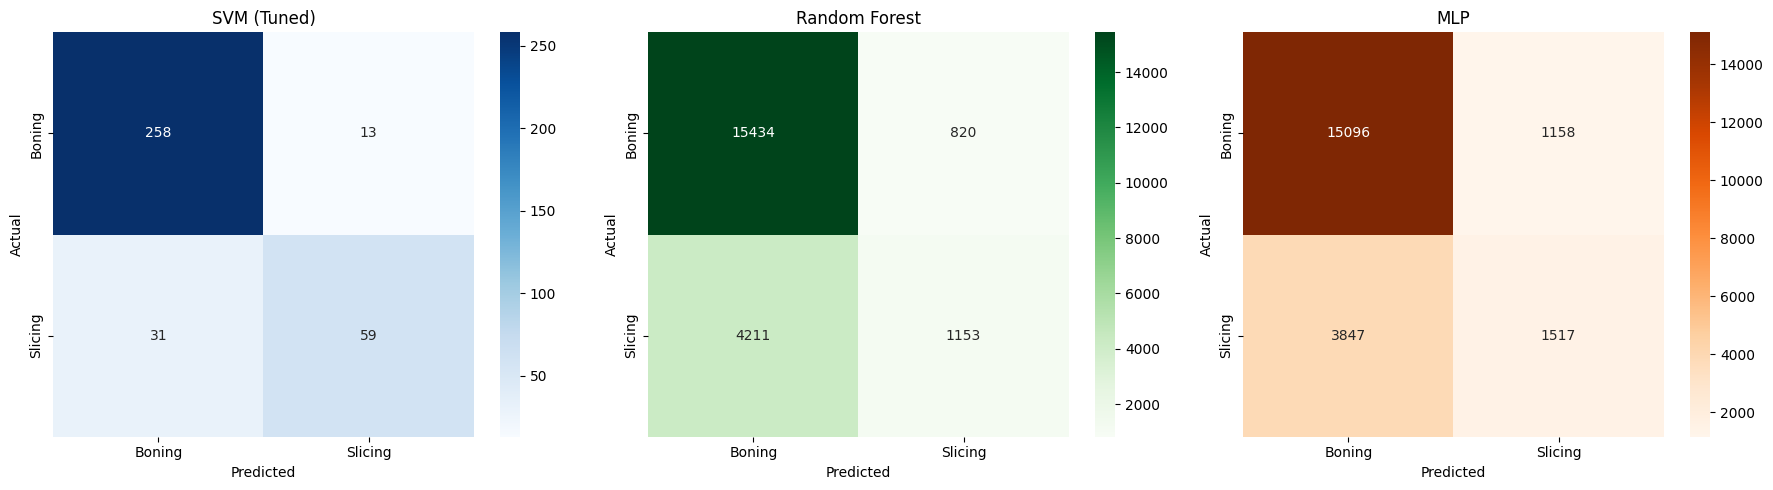

In [24]:
# Display final comparison of all models
print('========== FINAL MODEL COMPARISON ==========')
print(all_results_df.to_string(index=False))

# Confusion matrices for best models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Best SVM confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Boning', 'Slicing'], yticklabels=['Boning', 'Slicing'])
axes[0].set_title('SVM (Tuned)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test_orig, rf.predict(X_test_orig))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Boning', 'Slicing'], yticklabels=['Boning', 'Slicing'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# MLP confusion matrix
cm_mlp = confusion_matrix(y_test_orig, mlp.predict(X_test_orig))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Boning', 'Slicing'], yticklabels=['Boning', 'Slicing'])
axes[2].set_title('MLP')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [25]:
# Answer the following questions:
# 1. Which SVM configuration performed best?
print("Q9. So the SVM basic with default RBF kernel would be the one that performed the best among all the SVM configurations since it got a train-test accuracy of 0.8809 and a 10-fold CV accuracy of 0.8785. The hyperparameter-tuned SVM got very similar results with 0.8781 for train-test and 0.8768 for CV. Both of the dimensionality reduction approaches which are 10 best features and 10 PCA components resulted in lower accuracy which shows that the full 108-feature set has the most useful information for this classification task since reducing the features was actually losing too much useful information.")

# 2. Which machine learning algorithm performed best overall?
print("Q10. The SVM basic would be the one that got the highest accuracy overall with a train-test accuracy of 0.8809 and a 10-fold CV accuracy of 0.8785. The MLP classifier also showed strong results with 0.8615 for train-test and 0.8718 for 10-fold CV. Overall, SVM with the full feature set was the top performer for this task of telling apart boning and slicing.")

# 3. Why is this model suitable for this engineering problem?
print("Q11. SVM would be the one that is well-suited for this meat processing activity classification since it does well with lots of features like our 108 features by finding the best boundary to separate the classes using the kernel trick. The RBF kernel would be the one that captures the complex patterns between the acceleration features and the activity types while also being consistent as shown by the similar performance between the train-test and CV results. Not only that, telling apart two classes which are boning and slicing fits well with SVM since it is strong at two-class problems and it can also handle the uneven class sizes in the data which has around 903 boning minutes versus 298 slicing minutes.")

# 4. What are two limitations of your chosen model?
print("""Q12. The first limitation would be that the model does not handle the uneven class sizes well since the dataset has about a 3:1 ratio of boning to slicing samples. The model shows much lower recall for slicing which is around 0.67 compared to boning which is around 0.95 meaning it wrongly labels many slicing instances as boning. This could be a big issue in real use where correctly spotting all activity types is important since we would want the system to properly detect when a worker is slicing and not just label everything as boning.
      
The second limitation would be that the model does not track time patterns since the statistical feature approach looks at each minute on its own which loses the time-based connections between one minute and the next. In real meat processing, activities change smoothly and the current model cannot capture these time patterns or detect when the activity switches which limits how useful it is in like a real-time monitoring situation where knowing when a worker switches from boning to slicing or the other way around would be important.""")

Q9. So the SVM basic with default RBF kernel would be the one that performed the best among all the SVM configurations since it got a train-test accuracy of 0.8809 and a 10-fold CV accuracy of 0.8785. The hyperparameter-tuned SVM got very similar results with 0.8781 for train-test and 0.8768 for CV. Both of the dimensionality reduction approaches which are 10 best features and 10 PCA components resulted in lower accuracy which shows that the full 108-feature set has the most useful information for this classification task since reducing the features was actually losing too much useful information.
Q10. The SVM basic would be the one that got the highest accuracy overall with a train-test accuracy of 0.8809 and a 10-fold CV accuracy of 0.8785. The MLP classifier also showed strong results with 0.8615 for train-test and 0.8718 for 10-fold CV. Overall, SVM with the full feature set was the top performer for this task of telling apart boning and slicing.
Q11. SVM would be the one that is w

# INDEX

# 1
# Screenshots of chat available on Index Folder

print("Q2. Class labels are essential for supervised learning. To prove this, we train the same model twice:")
print("    - Once with CORRECT labels (the real answer key)")
print("    - Once with RANDOM/SHUFFLED labels (a fake answer key)\n")

X = dataset_combined[['Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z',
                       'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z']]
y = dataset_combined['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train with correct labels
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
real_acc = accuracy_score(y_test, clf.predict(X_test))

# Train with random shuffled labels
y_train_shuffled = np.random.permutation(y_train)
clf_random = DecisionTreeClassifier(random_state=42)
clf_random.fit(X_train, y_train_shuffled)
random_acc = accuracy_score(y_test, clf_random.predict(X_test))

print(f"Accuracy with CORRECT labels: {real_acc:.4f}")
print(f"Accuracy with RANDOM labels:  {random_acc:.4f}")
print(f"\nConclusion: With correct labels the model learns to distinguish boning from slicing.")
print(f"With random labels it performs near 50% (random guessing), proving labels are the answer key that enables learning.")

# 2
# SGD Classifier
sgd = SGDClassifier(random_state=42, max_iter=1000, class_weight='balanced')